# Telecom Customer Churn Prediction

A focused, reproducible analysis of the factors associated with customer churn and a leakage-safe comparison of classification models.

**Workflow:** data quality → exploratory analysis → preprocessing pipeline → cross-validated model selection → bounded tuning → untouched test evaluation.

## 1. Setup

The notebook uses a single random seed and a compact visual theme so results and charts are consistent across runs.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/churn-matplotlib-cache")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    ParameterGrid,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
CHURN_COLOR = "#E45756"
STAY_COLOR = "#4C78A8"
ACCENT_COLOR = "#72B7B2"
GRID_COLOR = "#D9E2EC"

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 110,
    "axes.facecolor": "#FAFBFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.alpha": 0.7,
    "grid.linewidth": 0.7,
    "legend.frameon": False,
    "font.size": 10,
})

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

## 2. Load and validate the data

`TotalCharges` contains blank strings for a small number of new customers. They are converted to missing values here and imputed inside the training pipeline later. The identifier is retained only for the quality check and is never used as a model feature.

In [2]:
data_candidates = [
    Path.cwd() / "data.csv",
    Path.cwd() / "Scripts" / "data.csv",
    Path.cwd().parent / "data.csv",
]
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not locate data.csv from the project root or Scripts directory.")

raw_data = pd.read_csv(DATA_PATH)
required_columns = {"customerID", "TotalCharges", "Churn"}
missing_columns = required_columns.difference(raw_data.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

data = raw_data.copy()
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

quality_summary = pd.DataFrame({
    "Value": [
        len(data),
        data.shape[1],
        data["customerID"].nunique(),
        int(data["customerID"].duplicated().sum()),
        int(data["TotalCharges"].isna().sum()),
        f"{data['Churn'].eq('Yes').mean():.1%}",
    ]
}, index=[
    "Rows",
    "Columns",
    "Unique customer IDs",
    "Duplicate customer IDs",
    "Missing TotalCharges",
    "Churn rate",
])

print(f"Loaded: {DATA_PATH.resolve()}")
display(quality_summary)
display(data.head())

Loaded: /Users/itag/Downloads/Telecom-Customer-Churn-prediction-main/data.csv


,Value
Rows,7043
Columns,21
Unique customer IDs,7043
Duplicate customer IDs,0
Missing TotalCharges,11
Churn rate,26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,"1,889.500",No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,"1,840.750",No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650,Yes


## 3. Exploratory analysis

### Churn overview

The target is imbalanced: most customers stay, so accuracy is useful for the requested selection objective but must be read alongside churn precision and recall.

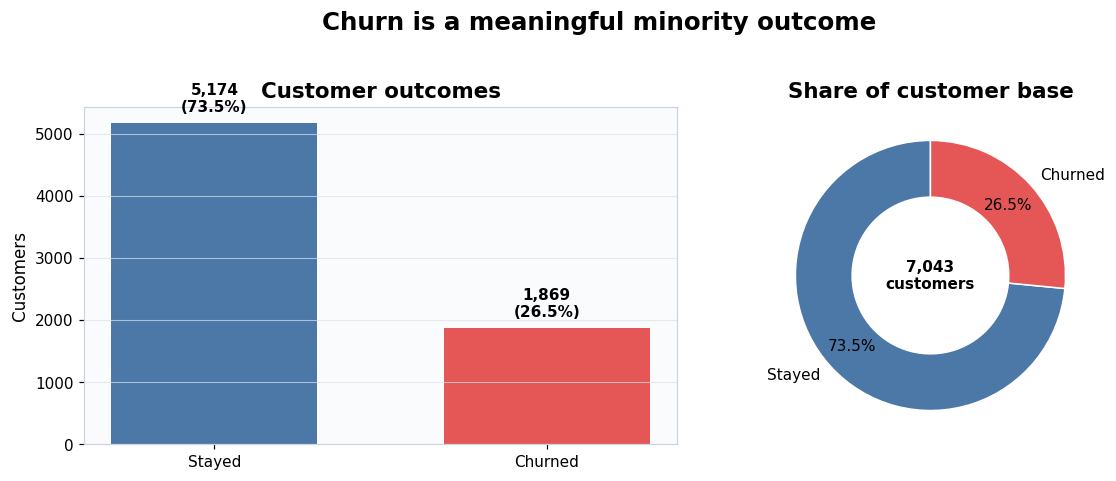

In [3]:
churn_counts = data["Churn"].value_counts().reindex(["No", "Yes"])
churn_rates = churn_counts / churn_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})

bars = axes[0].bar(
    ["Stayed", "Churned"],
    churn_counts.values,
    color=[STAY_COLOR, CHURN_COLOR],
    width=0.62,
)
axes[0].set_title("Customer outcomes")
axes[0].set_ylabel("Customers")
axes[0].grid(axis="x", visible=False)
for bar, count, rate in zip(bars, churn_counts, churn_rates):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + churn_counts.max() * 0.025,
        f"{count:,}\n({rate:.1%})",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

axes[1].pie(
    churn_counts.values,
    labels=["Stayed", "Churned"],
    colors=[STAY_COLOR, CHURN_COLOR],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops={"width": 0.42, "edgecolor": "white"},
)
axes[1].text(0, 0, f"{len(data):,}\ncustomers", ha="center", va="center", fontweight="bold")
axes[1].set_title("Share of customer base")

fig.suptitle("Churn is a meaningful minority outcome", fontsize=16, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

### Churn rates by service and account attributes

Rates are calculated directly from the current dataset. Each panel answers the same question: *what share of customers in this category churned?*

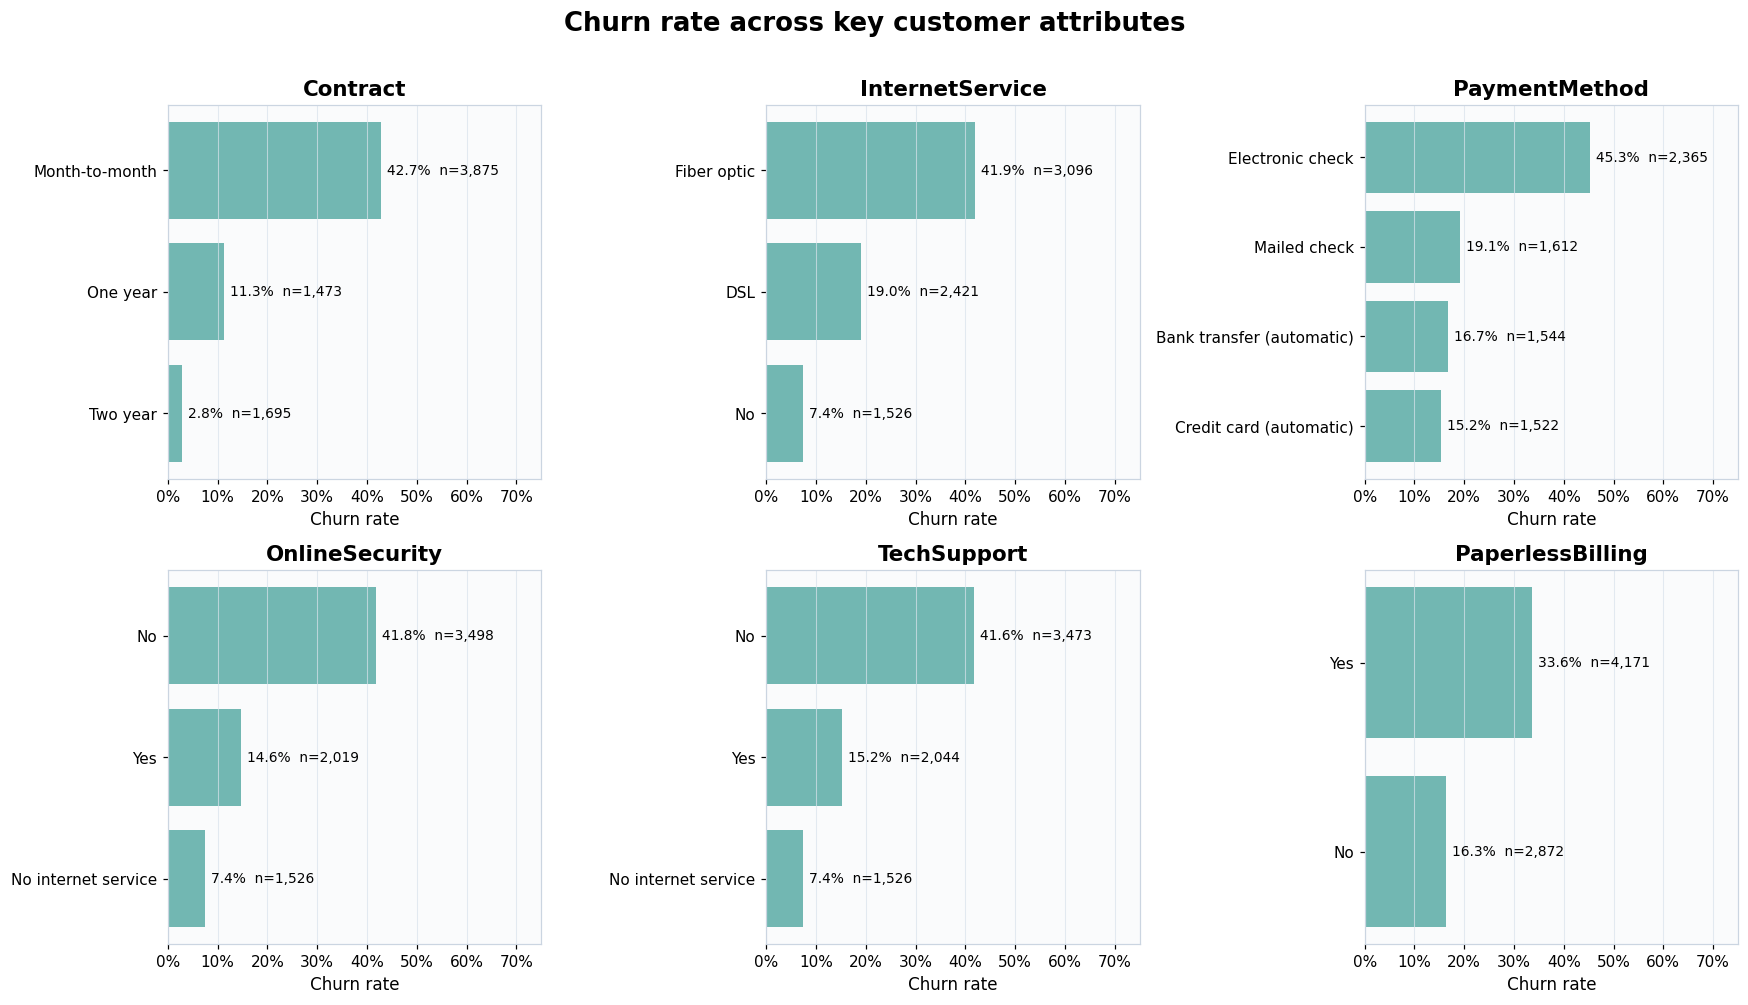

In [4]:
categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feature in zip(axes.flat, categorical_features):
    summary = (
        data.assign(Churned=data["Churn"].eq("Yes"))
        .groupby(feature, observed=True)["Churned"]
        .agg(["mean", "size"])
        .sort_values("mean")
    )
    bars = ax.barh(summary.index.astype(str), summary["mean"], color=ACCENT_COLOR)
    ax.set_title(feature)
    ax.set_xlabel("Churn rate")
    ax.set_xlim(0, max(0.75, summary["mean"].max() + 0.12))
    ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    ax.grid(axis="y", visible=False)
    for bar, rate, count in zip(bars, summary["mean"], summary["size"]):
        ax.text(
            rate + 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{rate:.1%}  n={count:,}",
            va="center",
            fontsize=9,
        )

fig.suptitle("Churn rate across key customer attributes", fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Tenure and charges

These distributions show how customer lifetime and spending differ between customers who stayed and those who churned.

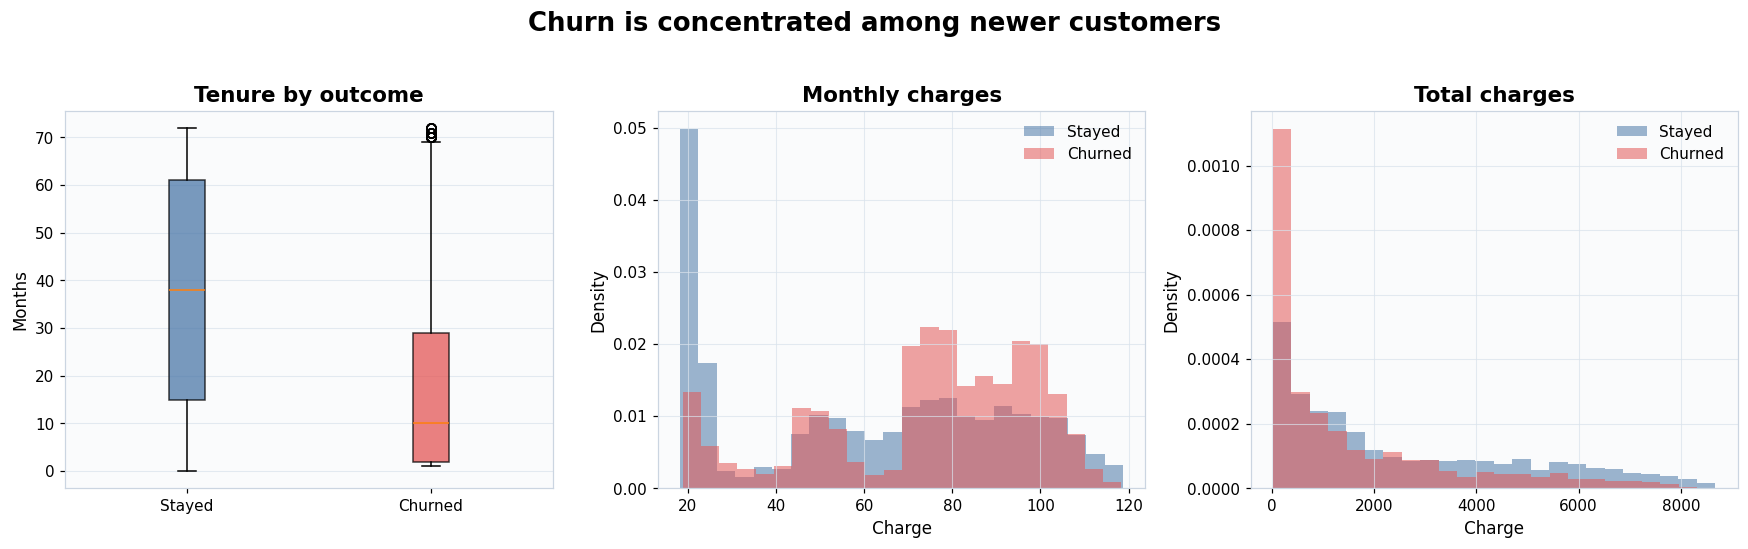

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

groups = [
    data.loc[data["Churn"].eq("No"), "tenure"],
    data.loc[data["Churn"].eq("Yes"), "tenure"],
]
box = axes[0].boxplot(groups, tick_labels=["Stayed", "Churned"], patch_artist=True)
for patch, color in zip(box["boxes"], [STAY_COLOR, CHURN_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_title("Tenure by outcome")
axes[0].set_ylabel("Months")
axes[0].grid(axis="x", visible=False)

for outcome, color, label in [("No", STAY_COLOR, "Stayed"), ("Yes", CHURN_COLOR, "Churned")]:
    subset = data.loc[data["Churn"].eq(outcome), "MonthlyCharges"]
    axes[1].hist(subset, bins=24, density=True, alpha=0.55, color=color, label=label)
axes[1].set_title("Monthly charges")
axes[1].set_xlabel("Charge")
axes[1].set_ylabel("Density")
axes[1].legend()

for outcome, color, label in [("No", STAY_COLOR, "Stayed"), ("Yes", CHURN_COLOR, "Churned")]:
    subset = data.loc[data["Churn"].eq(outcome), "TotalCharges"].dropna()
    axes[2].hist(subset, bins=24, density=True, alpha=0.55, color=color, label=label)
axes[2].set_title("Total charges")
axes[2].set_xlabel("Charge")
axes[2].set_ylabel("Density")
axes[2].legend()

fig.suptitle("Churn is concentrated among newer customers", fontsize=17, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 4. Leakage-safe preprocessing

The test set is isolated before fitting any imputer, encoder, or scaler. Within cross-validation, every preprocessing step is learned from that fold's training partition only.

In [6]:
X = data.drop(columns=["customerID", "Churn"])
y = data["Churn"].map({"No": 0, "Yes": 1})
if y.isna().any():
    raise ValueError("Churn must contain only 'Yes' and 'No' values.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

print(f"Training rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print(f"Numeric features: {len(numeric_features)} | Categorical features: {len(categorical_features)}")
print(f"Training churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}")

Training rows: 5,634 | Test rows: 1,409
Numeric features: 4 | Categorical features: 15
Training churn rate: 26.5% | Test churn rate: 26.5%


## 5. Cross-validated model comparison

Accuracy is the primary selection metric as requested. Precision, recall, F1, and ROC-AUC are carried alongside it to expose how each model treats the minority churn class.

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=1),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

comparison_rows = []
for name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", estimator),
    ])
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )
    comparison_rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
    })

model_results = (
    pd.DataFrame(comparison_rows)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)
display(model_results.style.format({column: "{:.3f}" for column in model_results.columns if column != "Model"}))

,Model,Accuracy,Accuracy SD,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.803,0.011,0.661,0.534,0.590,0.848
1,AdaBoost,0.803,0.012,0.657,0.542,0.593,0.848
2,Logistic Regression,0.802,0.012,0.653,0.543,0.592,0.846
3,Random Forest,0.786,0.013,0.627,0.484,0.545,0.821
4,Extra Trees,0.769,0.011,0.579,0.474,0.521,0.788
5,Decision Tree,0.728,0.008,0.488,0.488,0.488,0.651


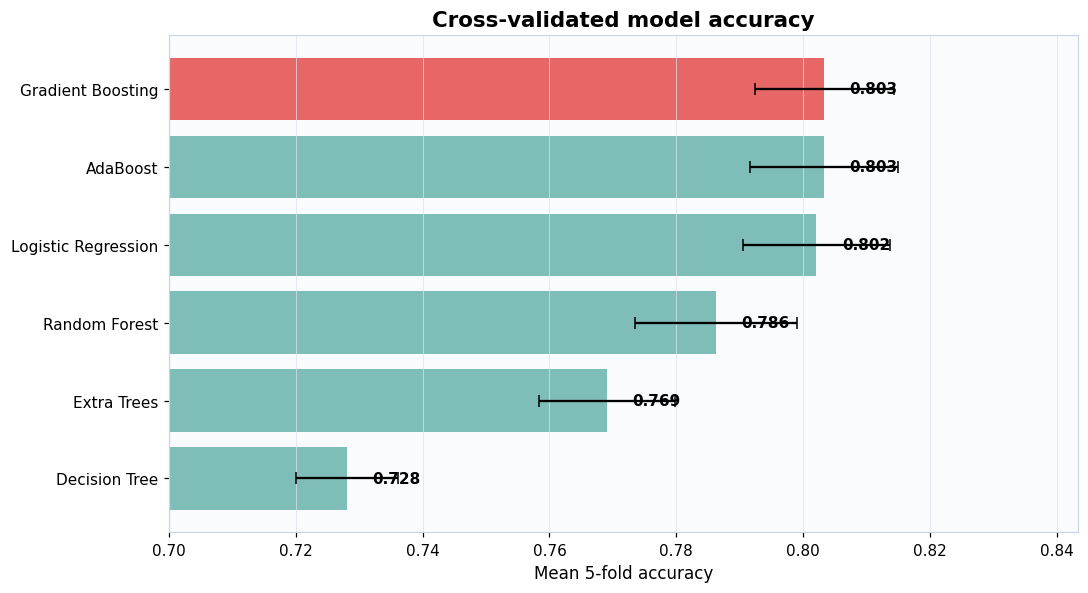

In [8]:
plot_data = model_results.sort_values("Accuracy")
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = [ACCENT_COLOR] * len(plot_data)
colors[-1] = CHURN_COLOR
bars = ax.barh(
    plot_data["Model"],
    plot_data["Accuracy"],
    xerr=plot_data["Accuracy SD"],
    color=colors,
    alpha=0.9,
    capsize=4,
)
ax.set_xlim(max(0.70, plot_data["Accuracy"].min() - 0.03), min(0.90, plot_data["Accuracy"].max() + 0.04))
ax.set_xlabel("Mean 5-fold accuracy")
ax.set_title("Cross-validated model accuracy")
ax.grid(axis="y", visible=False)
for bar, value in zip(bars, plot_data["Accuracy"]):
    ax.text(value + 0.004, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Bounded tuning of the leading model

Only the strongest cross-validated baseline is tuned. The search remains intentionally small to improve the model without turning this notebook into a long-running experiment.

In [9]:
search_spaces = {
    "Logistic Regression": {
        "model__C": [0.05, 0.1, 0.3, 0.7, 1.0, 2.0, 5.0],
    },
    "Decision Tree": {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 5, 8, 12, None],
        "model__min_samples_leaf": [1, 3, 6, 12],
    },
    "Random Forest": {
        "model__n_estimators": [200, 350, 500],
        "model__max_depth": [None, 8, 14, 20],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", 0.7],
    },
    "Extra Trees": {
        "model__n_estimators": [200, 350, 500],
        "model__max_depth": [None, 8, 14, 20],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", 0.7],
    },
    "AdaBoost": {
        "model__n_estimators": [50, 100, 150, 250],
        "model__learning_rate": [0.03, 0.1, 0.3, 0.7, 1.0],
    },
    "Gradient Boosting": {
        "model__n_estimators": [75, 100, 150, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [1, 2, 3],
        "model__subsample": [0.8, 1.0],
    },
}

leading_model_name = model_results.loc[0, "Model"]
leading_pipeline = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", clone(models[leading_model_name])),
])
parameter_space = search_spaces[leading_model_name]
n_iter = min(12, len(ParameterGrid(parameter_space)))

search = RandomizedSearchCV(
    estimator=leading_pipeline,
    param_distributions=parameter_space,
    n_iter=n_iter,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=False,
)
search.fit(X_train, y_train)

best_model = search.best_estimator_
print(f"Leading baseline: {leading_model_name}")
print(f"Best cross-validated accuracy: {search.best_score_:.3f}")
print("Best parameters:")
for parameter, value in search.best_params_.items():
    print(f"  {parameter.replace('model__', '')}: {value}")

Leading baseline: Gradient Boosting
Best cross-validated accuracy: 0.809
Best parameters:
  subsample: 0.8
  n_estimators: 200
  max_depth: 1
  learning_rate: 0.1


## 7. Final evaluation on the untouched test set

The holdout set is used once, after model selection and tuning. This produces the notebook's final estimate of generalization performance.

In [10]:
y_pred = best_model.predict(X_test)
y_probability = best_model.predict_proba(X_test)[:, 1]

test_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_probability),
}, name="Test score")

report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        target_names=["Stayed", "Churned"],
        output_dict=True,
        zero_division=0,
    )
).T

display(test_metrics.to_frame().style.format("{:.3f}"))
display(report.style.format("{:.3f}"))

,Test score
Accuracy,0.803
Precision,0.664
Recall,0.519
F1,0.583
ROC-AUC,0.848


,precision,recall,f1-score,support
Stayed,0.839,0.905,0.871,1035.000
Churned,0.664,0.519,0.583,374.000
accuracy,0.803,0.803,0.803,0.803
macro avg,0.752,0.712,0.727,1409.000
weighted avg,0.793,0.803,0.794,1409.000


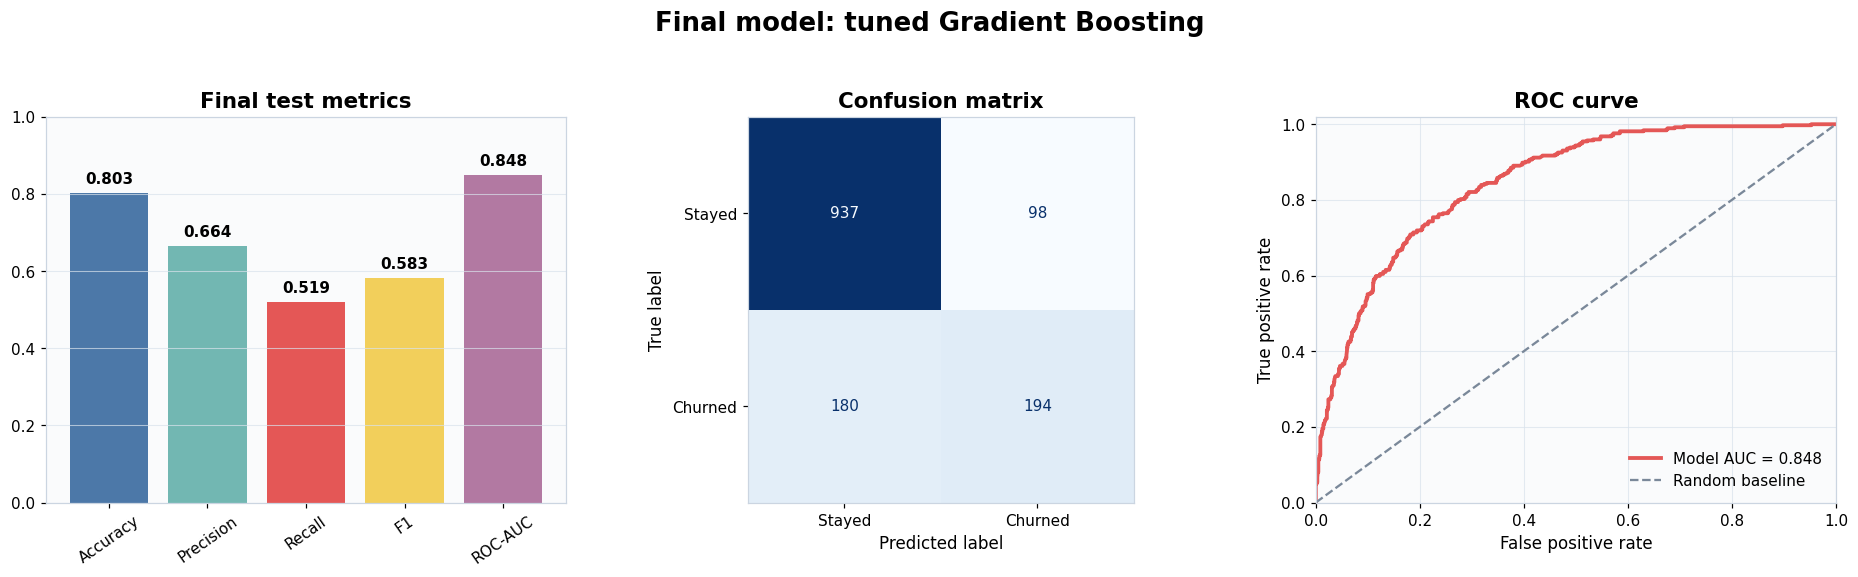

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

metric_bars = axes[0].bar(
    test_metrics.index,
    test_metrics.values,
    color=[STAY_COLOR, ACCENT_COLOR, CHURN_COLOR, "#F2CF5B", "#B279A2"],
)
axes[0].set_ylim(0, 1)
axes[0].set_title("Final test metrics")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="x", visible=False)
for bar, value in zip(metric_bars, test_metrics.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.025, f"{value:.3f}", ha="center", fontweight="bold")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=["Stayed", "Churned"],
).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=",d")
axes[1].set_title("Confusion matrix")
axes[1].grid(False)

fpr, tpr, _ = roc_curve(y_test, y_probability)
axes[2].plot(fpr, tpr, color=CHURN_COLOR, linewidth=2.5, label=f"Model AUC = {test_metrics['ROC-AUC']:.3f}")
axes[2].plot([0, 1], [0, 1], linestyle="--", color="#7A8899", label="Random baseline")
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1.02)
axes[2].set_xlabel("False positive rate")
axes[2].set_ylabel("True positive rate")
axes[2].set_title("ROC curve")
axes[2].legend(loc="lower right")

fig.suptitle(f"Final model: tuned {leading_model_name}", fontsize=17, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

## 8. What drives the final model?

For models with native coefficients or feature importance, the transformed features are shown directly. A permutation-based fallback keeps this section valid for any future estimator placed in the comparison.

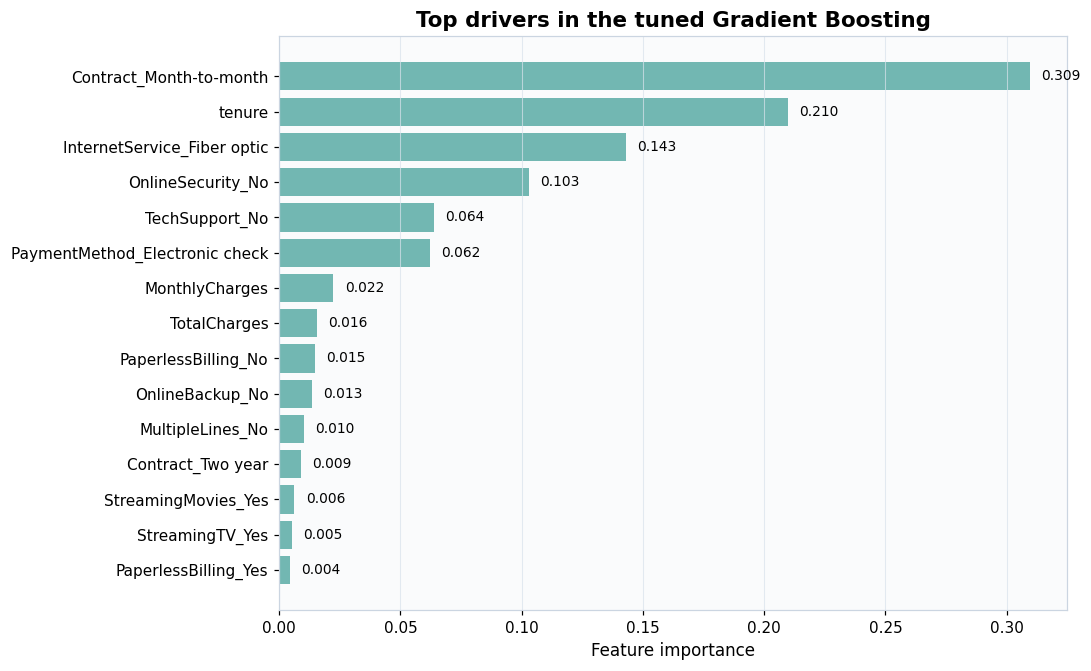

In [12]:
fitted_preprocessor = best_model.named_steps["preprocess"]
fitted_estimator = best_model.named_steps["model"]
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(fitted_estimator, "feature_importances_"):
    importance_values = fitted_estimator.feature_importances_
    importance_label = "Feature importance"
elif hasattr(fitted_estimator, "coef_"):
    importance_values = np.abs(fitted_estimator.coef_).ravel()
    importance_label = "Absolute coefficient"
else:
    permutation = permutation_importance(
        best_model,
        X_test,
        y_test,
        scoring="accuracy",
        n_repeats=8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    transformed_feature_names = np.array(X.columns)
    importance_values = permutation.importances_mean
    importance_label = "Permutation importance"

importance = (
    pd.DataFrame({"Feature": transformed_feature_names, "Importance": importance_values})
    .assign(Feature=lambda frame: frame["Feature"].str.replace(r"^(numeric|categorical)__", "", regex=True))
    .nlargest(15, "Importance")
    .sort_values("Importance")
)

fig, ax = plt.subplots(figsize=(10, 6.2))
bars = ax.barh(importance["Feature"], importance["Importance"], color=ACCENT_COLOR)
ax.set_xlabel(importance_label)
ax.set_title(f"Top drivers in the tuned {leading_model_name}")
ax.grid(axis="y", visible=False)
for bar, value in zip(bars, importance["Importance"]):
    ax.text(value + importance["Importance"].max() * 0.015, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 9. Conclusion

This notebook now provides a reproducible model comparison without preprocessing leakage or hardcoded analytical results. Accuracy remains the selection objective, while churn-specific metrics make the operational tradeoff visible.

In [13]:
print(
    f"Selected model: tuned {leading_model_name}\n"
    f"Cross-validated accuracy: {search.best_score_:.3f}\n"
    f"Holdout accuracy: {test_metrics['Accuracy']:.3f}\n"
    f"Holdout churn recall: {test_metrics['Recall']:.3f}\n"
    f"Holdout ROC-AUC: {test_metrics['ROC-AUC']:.3f}"
)

Selected model: tuned Gradient Boosting
Cross-validated accuracy: 0.809
Holdout accuracy: 0.803
Holdout churn recall: 0.519
Holdout ROC-AUC: 0.848
